In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [2]:
# Cargar el dataset
df = pd.read_csv("../data/heart.csv")

# Mostrar las primeras filas
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
# Número de filas y columnas
df.shape

(1025, 14)

In [5]:
# Estadísticas descriptivas
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
# Verificar valores nulos
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
# Distribución de la variable objetivo
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

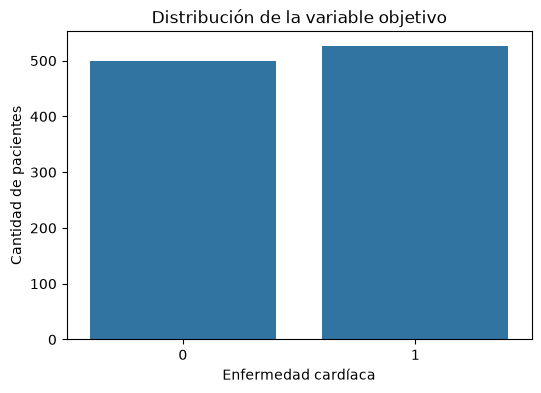

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Enfermedad cardíaca")
plt.ylabel("Cantidad de pacientes")

plt.show()

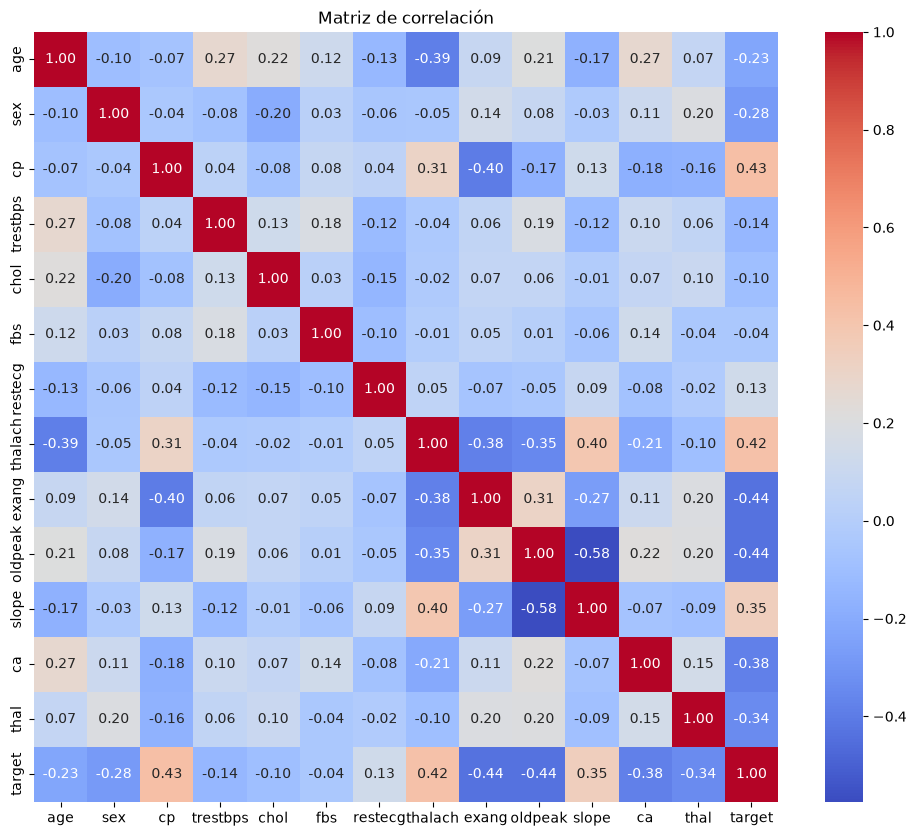

In [9]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matriz de correlación")

plt.show()

In [10]:
# Variables independientes (X) y variable objetivo (y)
X = df.drop("target", axis=1)
y = df["target"]

print("X:", X.shape)
print("y:", y.shape)

X: (1025, 13)
y: (1025,)


In [11]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (820, 13)
Prueba: (205, 13)


In [12]:
# Escalado de variables
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Escalado completado")

Escalado completado


In [13]:
# Modelo de Regresión Logística
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [14]:
# Predicciones
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 1 0 1 0 1 0 0 1 0]


In [15]:
# Accuracy del modelo
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7951


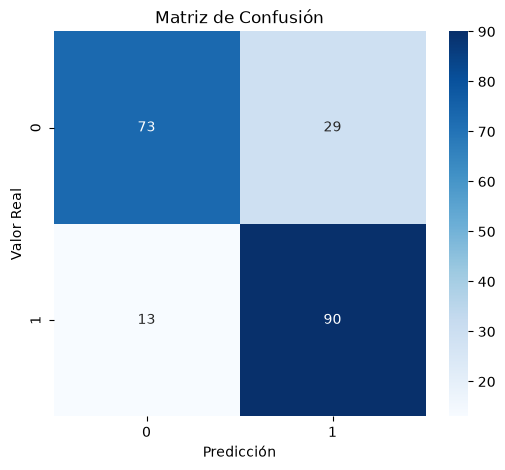

In [16]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [17]:
# Reporte de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



In [18]:
# Guardar modelo y escalador
joblib.dump(model, "../models/heart_disease_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Modelo y escalador guardados correctamente")

Modelo y escalador guardados correctamente


In [19]:
# Modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest entrenado correctamente")

Random Forest entrenado correctamente


In [20]:
rf_pred = rf_model.predict(X_test)

In [21]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Accuracy Random Forest: {rf_accuracy:.4f}")

Accuracy Random Forest: 0.9854


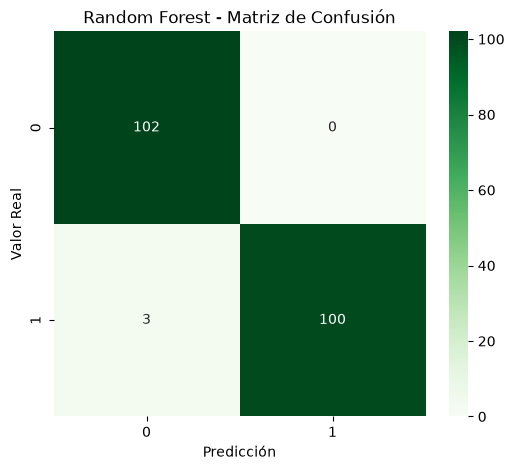

In [22]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest - Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [23]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [24]:
joblib.dump(rf_model, "../models/random_forest_model.pkl")

print("Random Forest guardado correctamente")

Random Forest guardado correctamente
